<a href="https://colab.research.google.com/github/camjanada/DS-4002-Projects/blob/main/ds_4002_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shawn
Data extraction and cleaning: Select sample size during established time period, establish inclusion criteria, clean/missing values, standardize score, create final dataset, document preprocessing/data cleaning

Arya
Variable creation and exploration: Create normalized score, polarization criteria, word count, FK Grade Level variables, examine distribution/outliers, create plots, write feature/EDA

Zichen
Model dev: Fit multi linear regression, assess model assumptions, examine stat/coefficients, calculate R^2 and interpret, create tables/graphs

Camila
Model testing: apply model to new data, evaluate regression, evaluate accuracy against baseline, organize GitHub Repo



CSV FILES (BOTH CLEANED AND WITH FEATURES):
https://drive.google.com/drive/folders/14gE2z4sTJd5kcWBaYWicY1giCTnCHNyU?usp=sharing

In [3]:
from google.colab import files

cleaned_data = files.upload()


Saving rotten_tomatoes_data_with_vars (1).csv to rotten_tomatoes_data_with_vars (1).csv


In [4]:
import io
import pandas as pd

movie_data = next(iter(cleaned_data))
df = pd.read_csv(io.BytesIO(cleaned_data[movie_data]))
#needed to look up the best way to upload this data into colab.

print(df.shape)
df.head()

(120622, 17)


,id,reviewId,creationDate,criticName,isTopCritic,standardizedScore,scoreType,reviewState,publicationName,reviewText,scoreSentiment,reviewUrl,normalized_score,polarization,word_count,fk_grade_level,grade_level
0,small_town_wisconsin,102700937,6/16/2022,Sumner Forbes,False,85.0,fraction,fresh,Film Threat,Small Town Wisconsin is a success in almost ev...,POSITIVE,https://filmthreat.com/reviews/small-town-wisc...,0.85,0.35,30,12.630000,12.630000
1,small_town_wisconsin,102699897,6/14/2022,Tara McNamara,False,60.0,fraction,fresh,Common Sense Media,Just like Wayne&#44; Small Town Wisconsin has ...,POSITIVE,https://www.commonsensemedia.org/movie-reviews...,0.60,0.10,22,7.471818,7.471818
2,small_town_wisconsin,102698744,6/10/2022,Rob Thomas,False,75.0,fraction,fresh,"Capital Times (Madison, WI)",It&#8217;s a movie with its heart in the right...,POSITIVE,https://captimes.com/entertainment/screens/sma...,0.75,0.25,20,6.370000,6.370000
3,small_town_wisconsin,102698482,6/10/2022,Jackie K. Cooper,False,70.0,fraction,fresh,jackiekcooper.com,This is the kind of movie that draws you so de...,POSITIVE,https://www.youtube.com/watch?v=ATKTwDDUGsI,0.70,0.20,21,7.771429,7.771429
4,small_town_wisconsin,102695788,6/2/2022,Eddie Harrison,False,80.0,fraction,fresh,film-authority.com,&#8230;a warm-hearted story of everyday life t...,POSITIVE,https://film-authority.com/2022/06/02/small-to...,0.80,0.30,22,12.299091,12.299091


In [5]:
# Creating standardized score variable and polarization variable.
df["normalized_score"] = df["standardizedScore"]/100
df["polarization"] = (df["normalized_score"]-0.5).abs()
# 0.5 rating to either extreme for polarization

df[["standardizedScore", "normalized_score", "polarization"]].head()

,standardizedScore,normalized_score,polarization
0,85.0,0.85,0.35
1,60.0,0.60,0.10
2,75.0,0.75,0.25
3,70.0,0.70,0.20
4,80.0,0.80,0.30


In [6]:
# Creating word count variable.
df["word_count"] = df["reviewText"].str.split().str.len()
#separating each review with spaces and length counts
df[["reviewText", "word_count"]].head()

,reviewText,word_count
0,Small Town Wisconsin is a success in almost ev...,30
1,Just like Wayne&#44; Small Town Wisconsin has ...,22
2,It&#8217;s a movie with its heart in the right...,20
3,This is the kind of movie that draws you so de...,21
4,&#8230;a warm-hearted story of everyday life t...,22


In [7]:
# Flesch-Kincaid Grade Level - downloading textstat - package for the calculation that is necessary
%pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.0 MB/s eta 0:00:00


In [8]:
# establishing text grade level with flesch-kincaid grade level
import textstat
df["grade_level"] = df["reviewText"].apply(textstat.flesch_kincaid_grade)
df[["reviewText", "grade_level"]].head()

,reviewText,grade_level
0,Small Town Wisconsin is a success in almost ev...,12.630000
1,Just like Wayne&#44; Small Town Wisconsin has ...,7.471818
2,It&#8217;s a movie with its heart in the right...,6.370000
3,This is the kind of movie that draws you so de...,7.771429
4,&#8230;a warm-hearted story of everyday life t...,12.299091


In [9]:
#checking distributions and looking for unusual values
print(df[["normalized_score", "polarization", "word_count", "grade_level"]].describe())

       normalized_score   polarization     word_count    grade_level
count     120622.000000  120622.000000  120622.000000  120622.000000
mean           0.683028       0.222298      24.011739      11.765439
std            0.182859       0.132364       9.809461       4.443063
min            0.000000       0.000000       1.000000      -3.400000
25%            0.600000       0.100000      17.000000       8.588421
50%            0.700000       0.240000      24.000000      11.693684
75%            0.800000       0.300000      31.000000      14.958750
max            1.000000       0.500000      54.000000     126.400000


array([[<Axes: title={'center': 'word_count'}>,
        <Axes: title={'center': 'polarization'}>]], dtype=object)

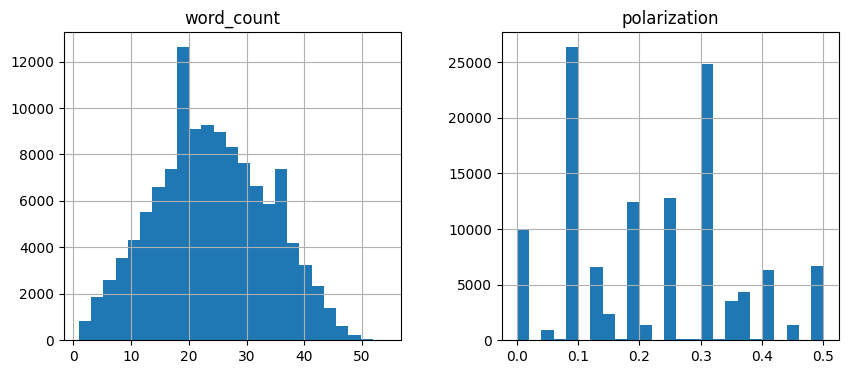

In [10]:
#exploratory plots
df[["word_count", "polarization"]].hist(
    bins=25,
    figsize=(10, 4)
)

# EDA: Movie reviews show a median length of 24 words with polarization values concentrated just under 0.1 and above 0.3.

<Axes: title={'center': 'average polarization by length of movie review'}, xlabel='word count', ylabel='average polarization'>

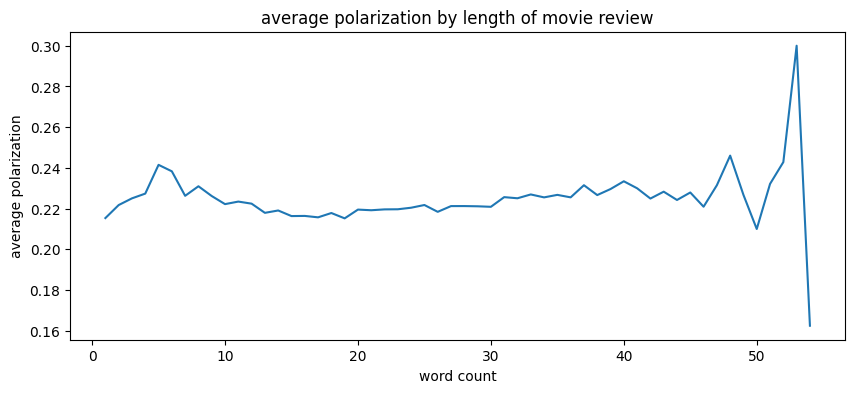

In [11]:
#length and polarization relationship
df.groupby("word_count")["polarization"].mean().plot(
    xlabel= "word count",
    ylabel = "average polarization",
    title = "average polarization by length of movie review",
    figsize=(10, 4)
)

# Average polarization looks to be around 0.2 across movie review lengths. Appears to have a weak relationship.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

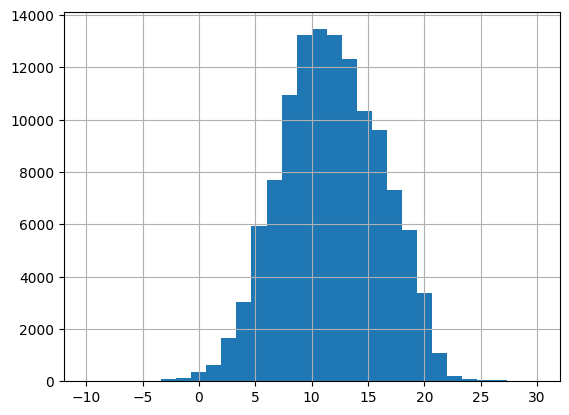

In [12]:
# looking at grade level distribution
df["grade_level"].hist(bins=30, range=(-10, 30))
# saving the features csv

df.to_csv("rotten_tomatoes_data_with_vars.csv", index=False)

from google.colab import files
files.download("rotten_tomatoes_data_with_vars.csv")

ZICHEN — FINAL MODEL SAMPLE AND SPLIT
Modeling observations: 120,622
Training set: 96,497 (80.0%)
Held-out test set: 24,125 (20.0%)
Split: 80% train / 20% test; random_state=42

COEFFICIENT TABLE — HC3 ROBUST STANDARD ERRORS


,coefficient,HC3_robust_SE,t_value,p_value,CI_95_lower,CI_95_upper,standardized_beta
const,0.22092,0.00292,75.76908,0.00000,0.21521,0.22664,NaN
log_word_count,-0.00649,0.00103,-6.31288,0.00000,-0.00851,-0.00448,-0.02292
grade_level_model,0.00190,0.00011,17.01552,0.00000,0.00168,0.00212,0.06216
is_top_critic,-0.00334,0.00111,-2.99186,0.00277,-0.00552,-0.00115,-0.00960



HELD-OUT PERFORMANCE AND BASELINE COMPARISON


,MAE,RMSE,R_squared
Final regression,0.11142,0.13210,0.00207
Training-mean baseline,0.11167,0.13223,-0.00001


Training R-squared: 0.00327
Adjusted training R-squared: 0.00324
Overall F-test p-value: 3.555e-68

VARIANCE INFLATION FACTORS


,predictor,VIF
0,log_word_count,1.242
1,grade_level_model,1.243
2,is_top_critic,1.003



REGRESSION DIAGNOSTICS


,diagnostic,statistic,p_value
0,Breusch-Pagan LM,7.11132,0.06843
1,Breusch-Pagan F,2.37052,0.06843
2,Jarque-Bera normality,2573.64391,0.00000
3,Ramsey RESET linearity,20.61343,0.00001
4,Durbin-Watson,1.99356,NaN


Residual skew: 0.219; residual kurtosis: 2.331


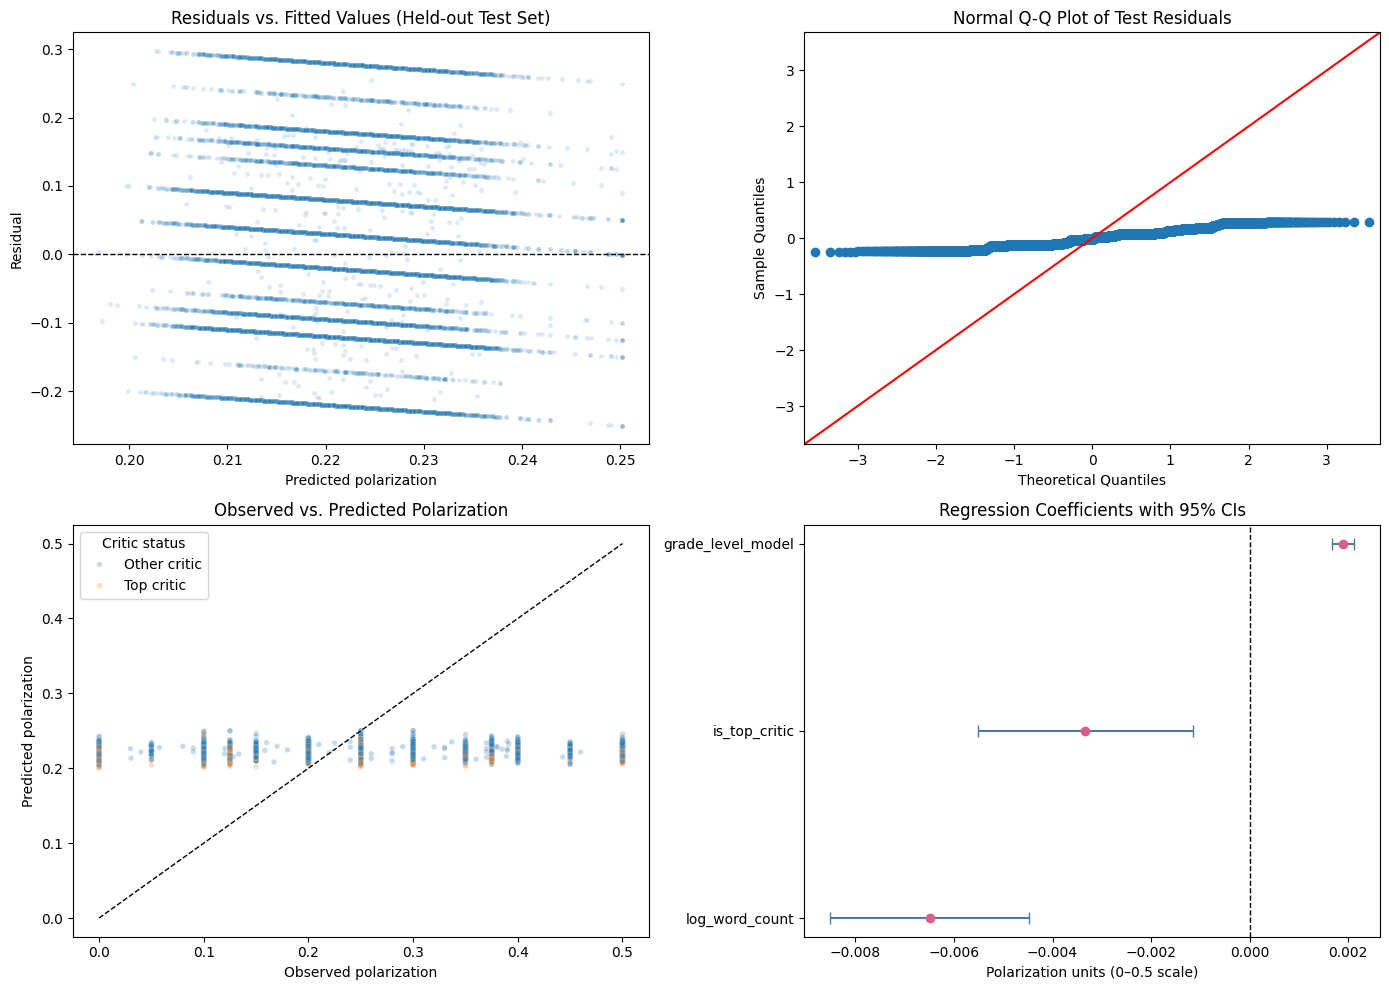


ZICHEN — MS3 MODEL CONCLUSION
Held-out R-squared: 0.00207
Baseline held-out R-squared: -0.00001
Predetermined R-squared >= 0.20 goal met: False
Statistical significance must be interpreted separately from predictive usefulness.
These findings are associative and do not support a causal conclusion.


In [13]:
"""Zichen Luo — MS3 model development.

This cell continues from the shared notebook's ``df`` DataFrame. It fits the
planned multiple linear regression, evaluates assumptions and held-out
performance, and produces tables and graphs for the report.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera


# --------------------------------------------------------------------------
# 1. Modeling dataset and reproducible 80/20 train-test split
# --------------------------------------------------------------------------
# Remove duplicate review IDs and rows missing a required modeling variable.
model_data = df.drop_duplicates(subset=["reviewId"]).copy()
model_data["is_top_critic"] = (
    model_data["isTopCritic"].astype(str).str.strip().str.lower().eq("true").astype(int)
)

# Winsorize continuous predictors at the 1st and 99th percentiles to reduce
# the influence of implausible/extreme values while retaining observations.
for source, target in [("word_count", "word_count_model"),
                       ("grade_level", "grade_level_model")]:
    lower, upper = model_data[source].quantile([0.01, 0.99])
    model_data[target] = model_data[source].clip(lower, upper)

model_data["log_word_count"] = np.log1p(model_data["word_count_model"])
features = ["log_word_count", "grade_level_model", "is_top_critic"]
model_data = (
    model_data[["polarization", *features]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# MIT2 clarification: 80% is used for fitting and 20% is held out for testing.
train_df, test_df = train_test_split(
    model_data,
    test_size=0.20,
    random_state=42,
)

X_train = sm.add_constant(train_df[features], has_constant="add")
X_test = sm.add_constant(test_df[features], has_constant="add")
y_train = train_df["polarization"]
y_test = test_df["polarization"]

print("ZICHEN — FINAL MODEL SAMPLE AND SPLIT")
print(f"Modeling observations: {len(model_data):,}")
print(f"Training set: {len(train_df):,} ({len(train_df) / len(model_data):.1%})")
print(f"Held-out test set: {len(test_df):,} ({len(test_df) / len(model_data):.1%})")
print("Split: 80% train / 20% test; random_state=42")


# --------------------------------------------------------------------------
# 2. Multiple linear regression and HC3 robust statistical inference
# --------------------------------------------------------------------------
ols = sm.OLS(y_train, X_train).fit()
robust_model = sm.OLS(y_train, X_train).fit(cov_type="HC3")
test_predictions = robust_model.predict(X_test)
baseline_predictions = np.repeat(y_train.mean(), len(y_test))


def metric_row(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R_squared": r2_score(actual, predicted),
    }


performance_table = pd.DataFrame(
    {
        "Final regression": metric_row(y_test, test_predictions),
        "Training-mean baseline": metric_row(y_test, baseline_predictions),
    }
).T

# Standardized coefficients provide comparable effect-size estimates.
X_train_z = train_df[features].apply(lambda s: (s - s.mean()) / s.std(ddof=0))
y_train_z = (y_train - y_train.mean()) / y_train.std(ddof=0)
standardized_model = sm.OLS(
    y_train_z,
    sm.add_constant(X_train_z, has_constant="add"),
).fit(cov_type="HC3")

confidence_intervals = np.asarray(robust_model.conf_int())
coefficient_table = pd.DataFrame(
    {
        "coefficient": np.asarray(robust_model.params),
        "HC3_robust_SE": np.asarray(robust_model.bse),
        "t_value": np.asarray(robust_model.tvalues),
        "p_value": np.asarray(robust_model.pvalues),
        "CI_95_lower": confidence_intervals[:, 0],
        "CI_95_upper": confidence_intervals[:, 1],
        "standardized_beta": [np.nan, *np.asarray(standardized_model.params)[1:]],
    },
    index=X_train.columns,
)

print("\nCOEFFICIENT TABLE — HC3 ROBUST STANDARD ERRORS")
display(coefficient_table.round(5))
print("\nHELD-OUT PERFORMANCE AND BASELINE COMPARISON")
display(performance_table.round(5))
print(f"Training R-squared: {ols.rsquared:.5f}")
print(f"Adjusted training R-squared: {ols.rsquared_adj:.5f}")
print(f"Overall F-test p-value: {ols.f_pvalue:.4g}")


# --------------------------------------------------------------------------
# 3. Multicollinearity and model-assumption checks
# --------------------------------------------------------------------------
vif_design = sm.add_constant(train_df[features], has_constant="add")
vif_table = pd.DataFrame(
    {
        "predictor": features,
        "VIF": [
            variance_inflation_factor(vif_design.to_numpy(), i)
            for i in range(1, len(features) + 1)
        ],
    }
)

bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(ols.resid, X_train)
jb_stat, jb_p, residual_skew, residual_kurtosis = jarque_bera(ols.resid)
reset_test = linear_reset(ols, power=2, use_f=True)

diagnostic_table = pd.DataFrame(
    {
        "diagnostic": [
            "Breusch-Pagan LM",
            "Breusch-Pagan F",
            "Jarque-Bera normality",
            "Ramsey RESET linearity",
            "Durbin-Watson",
        ],
        "statistic": [
            bp_lm,
            bp_f,
            jb_stat,
            float(reset_test.fvalue),
            durbin_watson(ols.resid),
        ],
        "p_value": [bp_lm_p, bp_f_p, jb_p, float(reset_test.pvalue), np.nan],
    }
)

print("\nVARIANCE INFLATION FACTORS")
display(vif_table.round(3))
print("\nREGRESSION DIAGNOSTICS")
display(diagnostic_table.round(5))
print(f"Residual skew: {residual_skew:.3f}; residual kurtosis: {residual_kurtosis:.3f}")


# --------------------------------------------------------------------------
# 4. Presentation-ready model and diagnostic graphs
# --------------------------------------------------------------------------
test_residuals = y_test - test_predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(x=test_predictions, y=test_residuals, alpha=0.15, s=12, ax=axes[0, 0])
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0, 0].set(
    title="Residuals vs. Fitted Values (Held-out Test Set)",
    xlabel="Predicted polarization",
    ylabel="Residual",
)

qq_residuals = test_residuals.sample(n=min(5_000, len(test_residuals)), random_state=42)
sm.qqplot(qq_residuals, line="45", ax=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q Plot of Test Residuals")

plot_indices = test_df.sample(n=min(5_000, len(test_df)), random_state=42).index
sns.scatterplot(
    x=y_test.loc[plot_indices],
    y=test_predictions.loc[plot_indices],
    hue=test_df.loc[plot_indices, "is_top_critic"].map(
        {0: "Other critic", 1: "Top critic"}
    ),
    alpha=0.25,
    s=16,
    ax=axes[1, 0],
)
plot_min, plot_max = y_test.min(), y_test.max()
axes[1, 0].plot([plot_min, plot_max], [plot_min, plot_max], "k--", linewidth=1)
axes[1, 0].set(
    title="Observed vs. Predicted Polarization",
    xlabel="Observed polarization",
    ylabel="Predicted polarization",
)
axes[1, 0].legend(title="Critic status")

plot_coefficients = coefficient_table.drop(index="const").sort_values("coefficient")
axes[1, 1].errorbar(
    plot_coefficients["coefficient"],
    plot_coefficients.index,
    xerr=[
        plot_coefficients["coefficient"] - plot_coefficients["CI_95_lower"],
        plot_coefficients["CI_95_upper"] - plot_coefficients["coefficient"],
    ],
    fmt="o",
    color="#d65f8d",
    ecolor="#4e79a7",
    capsize=4,
)
axes[1, 1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set(
    title="Regression Coefficients with 95% CIs",
    xlabel="Polarization units (0–0.5 scale)",
)

plt.tight_layout()
plt.show()


# --------------------------------------------------------------------------
# 5. Direct interpretation against the team's predetermined R-squared goal
# --------------------------------------------------------------------------
final_r2 = performance_table.loc["Final regression", "R_squared"]
baseline_r2 = performance_table.loc["Training-mean baseline", "R_squared"]

print("\nZICHEN — MS3 MODEL CONCLUSION")
print(f"Held-out R-squared: {final_r2:.5f}")
print(f"Baseline held-out R-squared: {baseline_r2:.5f}")
print(f"Predetermined R-squared >= 0.20 goal met: {final_r2 >= 0.20}")
print("Statistical significance must be interpreted separately from predictive usefulness.")
print("These findings are associative and do not support a causal conclusion.")


In [14]:
# Load the feature-engineered CSV already uploaded to this Colab runtime.
import os
import pandas as pd

FEATURE_DATA_PATH = "/content/rotten_tomatoes_data_with_vars.csv"
assert os.path.exists(FEATURE_DATA_PATH), "Feature CSV is missing from the Colab runtime."
df = pd.read_csv(FEATURE_DATA_PATH)

print(f"Loaded feature dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("Required columns present:", {
    c: c in df.columns
    for c in ["reviewId", "isTopCritic", "polarization", "word_count", "grade_level"]
})


Loaded feature dataset: 120,622 rows x 17 columns
Required columns present: {'reviewId': True, 'isTopCritic': True, 'polarization': True, 'word_count': True, 'grade_level': True}


CAMILA — MODEL TESTING
Training set: 96,497 | Held-out set (not used in fitting): 24,125

FINALIZED REGRESSION EQUATION (fit on training data):
polarization = 0.2209 + -0.0065*log(1 + word_count) + 0.0019*grade_level + -0.0033*top_critic

PERFORMANCE METRICS: MODEL vs. BASELINE


R_squared      MAE     RMSE  \
In-sample (training) Final regression           0.00327  0.11162  0.13218   
                     Intercept-only baseline    0.00000  0.11193  0.13240   
Held-out (new data)  Final regression           0.00207  0.11142  0.13210   
                     Training-mean baseline    -0.00001  0.11167  0.13223   

                                              Accuracy_±0.5  
In-sample (training) Final regression                   1.0  
                     Intercept-only baseline            1.0  
Held-out (new data)  Final regression                   1.0  
                     Training-mean baseline             1.0


TRAINING vs. HELD-OUT RESULTS (generalization check)


,Training,Held-out,Difference (held-out − training)
R_squared,0.00327,0.00207,-0.00120
MAE,0.11162,0.11142,-0.00020
RMSE,0.13218,0.13210,-0.00008



PLAN CRITERIA CHECK


,stage,criterion,met
0,In-sample,R² > 0,YES
1,In-sample,MAE below intercept-only baseline,YES
2,In-sample,RMSE below intercept-only baseline,YES
3,Held-out,R² > 0,YES
4,Held-out,MAE below training-mean baseline,YES
5,Held-out,RMSE below training-mean baseline,YES
6,Goal,Held-out R² > 0.2,NO
7,Goal,≥70% of predictions within ±0.5,YES


R² gap (training − held-out): 0.00120 (a small gap means the model generalizes beyond the training sample)


HELD-OUT ACCURACY AT DIFFERENT MARGINS OF ERROR


,Final regression,Training-mean baseline
within ±0.05,22.3%,22.3%
within ±0.1,48.8%,50.3%
within ±0.25,94.4%,94.4%
within ±0.5,100.0%,100.0%


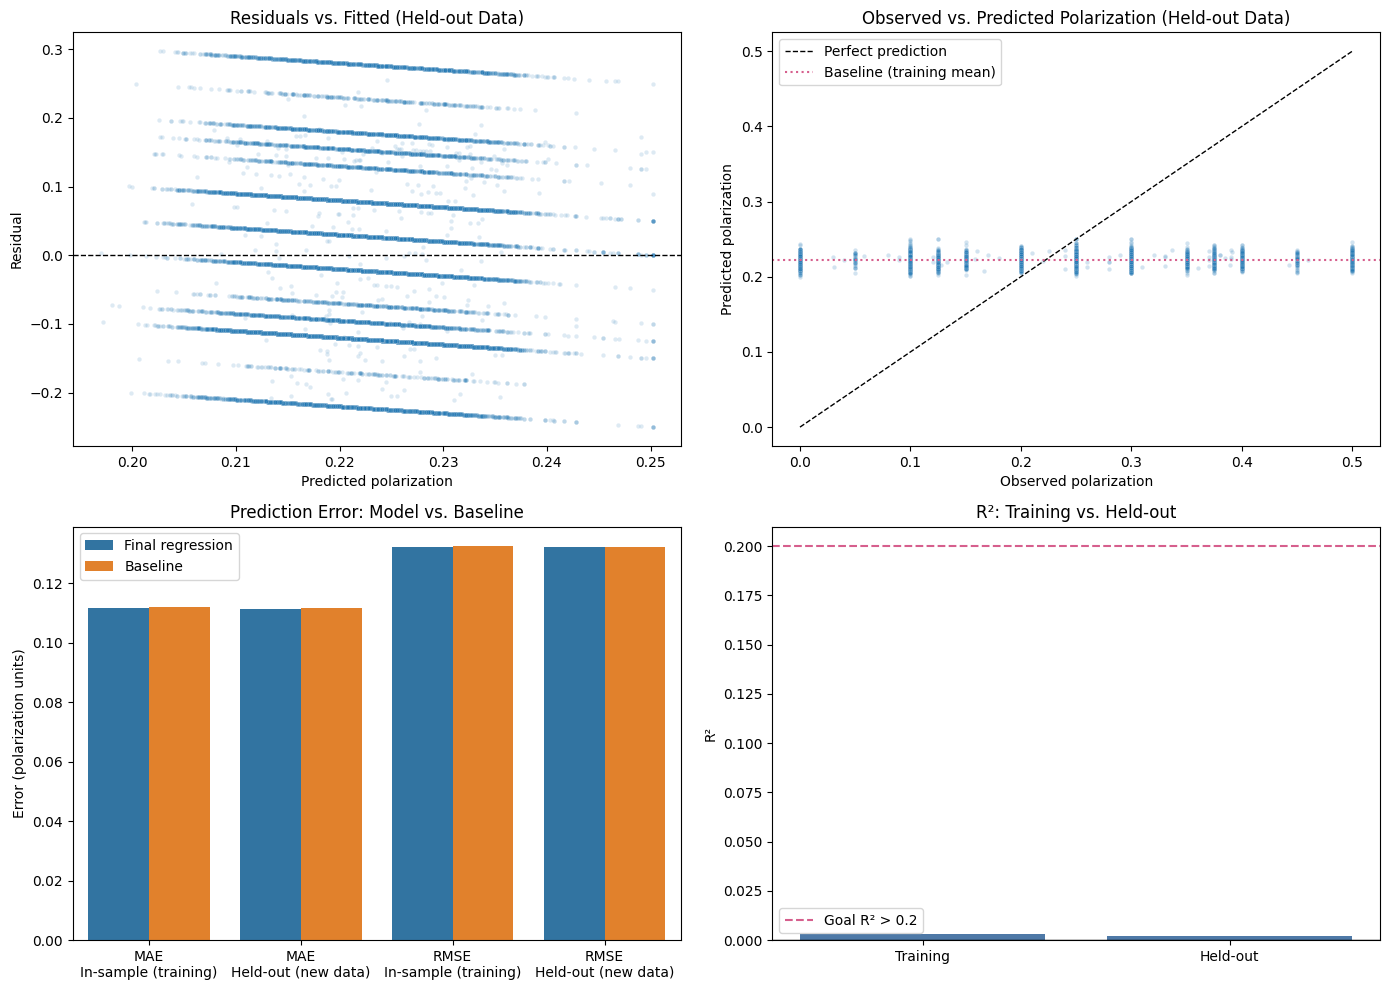


CAMILA — MODEL TESTING CONCLUSION
Training R²: 0.00327 | Held-out R²: 0.00207
Held-out MAE: model 0.11142 vs. baseline 0.11167
Held-out RMSE: model 0.13210 vs. baseline 0.13223
Model beats the training-mean baseline on new data: YES
R² goal (> 0.2) met: NO


In [15]:
# Camila

#packages & variables
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

R2_GOAL = 0.20          # plan: R² > 20%
TOLERANCE = 0.5         # plan: "margin of error of ± 0.5" (see warning in section 3)
ACCURACY_GOAL = 0.70    # plan: 70% accuracy

#======================================================
#ensure previous code ran through
for name in ["robust_model", "X_train", "X_test", "y_train", "y_test"]:
    if name not in globals():
        raise NameError(f"'{name}' not found — run Zichen's model cell first.")

final_model = robust_model
print("CAMILA — MODEL TESTING")
print(f"Training set: {len(y_train):,} | Held-out set (not used in fitting): {len(y_test):,}")

b = final_model.params
print("\nFINALIZED REGRESSION EQUATION (fit on training data):")
print(f"polarization = {b['const']:.4f} "
      f"+ {b['log_word_count']:.4f}*log(1 + word_count) "
      f"+ {b['grade_level_model']:.4f}*grade_level "
      f"+ {b['is_top_critic']:.4f}*top_critic")

#=====================================================
# 1. Performance metrics — model vs. baseline, in-sample and held-out
#=====================================================
train_mean = y_train.mean()   # baseline uses ONLY the training mean

pred_train = final_model.predict(X_train)
pred_test = final_model.predict(X_test)      # apply equation to new reviews
base_train = np.full(len(y_train), train_mean)
base_test = np.full(len(y_test), train_mean)


def metrics(actual, predicted):
    actual, predicted = np.asarray(actual), np.asarray(predicted)
    return {
        "R_squared": r2_score(actual, predicted),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        f"Accuracy_±{TOLERANCE}": np.mean(np.abs(actual - predicted) <= TOLERANCE),
    }


performance = pd.DataFrame(
    {
        ("In-sample (training)", "Final regression"): metrics(y_train, pred_train),
        ("In-sample (training)", "Intercept-only baseline"): metrics(y_train, base_train),
        ("Held-out (new data)", "Final regression"): metrics(y_test, pred_test),
        ("Held-out (new data)", "Training-mean baseline"): metrics(y_test, base_test),
    }
).T
print("\nPERFORMANCE METRICS: MODEL vs. BASELINE")
display(performance.round(5))

train_row = performance.loc[("In-sample (training)", "Final regression")]
test_row = performance.loc[("Held-out (new data)", "Final regression")]
train_base = performance.loc[("In-sample (training)", "Intercept-only baseline")]
test_base = performance.loc[("Held-out (new data)", "Training-mean baseline")]

generalization = pd.DataFrame(
    {"Training": train_row[["R_squared", "MAE", "RMSE"]],
     "Held-out": test_row[["R_squared", "MAE", "RMSE"]]}
)
generalization["Difference (held-out − training)"] = (
    generalization["Held-out"] - generalization["Training"]
)
print("\nTRAINING vs. HELD-OUT RESULTS (generalization check)")
display(generalization.round(5))

#=====================================================
# 2. Evaluate the plan's criteria
#=====================================================
def yes_no(condition):
    return "YES" if condition else "NO"


criteria = pd.DataFrame(
    [
        ("In-sample", "R² > 0", yes_no(train_row["R_squared"] > 0)),
        ("In-sample", "MAE below intercept-only baseline", yes_no(train_row["MAE"] < train_base["MAE"])),
        ("In-sample", "RMSE below intercept-only baseline", yes_no(train_row["RMSE"] < train_base["RMSE"])),
        ("Held-out", "R² > 0", yes_no(test_row["R_squared"] > 0)),
        ("Held-out", "MAE below training-mean baseline", yes_no(test_row["MAE"] < test_base["MAE"])),
        ("Held-out", "RMSE below training-mean baseline", yes_no(test_row["RMSE"] < test_base["RMSE"])),
        ("Goal", f"Held-out R² > {R2_GOAL}", yes_no(test_row["R_squared"] > R2_GOAL)),
        ("Goal", f"≥{ACCURACY_GOAL:.0%} of predictions within ±{TOLERANCE}",
         yes_no(test_row[f"Accuracy_±{TOLERANCE}"] >= ACCURACY_GOAL)),
    ],
    columns=["stage", "criterion", "met"],
)
print("\nPLAN CRITERIA CHECK")
display(criteria)
print(f"R² gap (training − held-out): {train_row['R_squared'] - test_row['R_squared']:.5f} "
      "(a small gap means the model generalizes beyond the training sample)")

# ==============================================================================
# 3. Margin-of-error accuracy (context for the ±0.5 goal)
# ==============================================================================
if TOLERANCE >= 0.5:
    print(f"\nWARNING: polarization only ranges from 0 to 0.5, so a margin of ±{TOLERANCE} "
          "is met by almost any prediction. Accuracy at tighter margins is shown below.")

margins = [0.05, 0.10, 0.25, TOLERANCE]
margin_table = pd.DataFrame(
    {
        "Final regression": [np.mean(np.abs(y_test - pred_test) <= m) for m in margins],
        "Training-mean baseline": [np.mean(np.abs(y_test - base_test) <= m) for m in margins],
    },
    index=[f"within ±{m}" for m in margins],
)
print("\nHELD-OUT ACCURACY AT DIFFERENT MARGINS OF ERROR")
display(margin_table.style.format("{:.1%}"))


# ==============================================================================
# 4. Graphs for the report
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
test_resid = y_test - pred_test

# (a) Residuals vs. fitted on the new data
sns.scatterplot(x=pred_test, y=test_resid, alpha=0.15, s=10, ax=axes[0, 0])
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0, 0].set(title="Residuals vs. Fitted (Held-out Data)",
               xlabel="Predicted polarization", ylabel="Residual")

# (b) Observed vs. predicted on the new data
sample_idx = y_test.sample(n=min(5_000, len(y_test)), random_state=42).index
sns.scatterplot(x=y_test.loc[sample_idx], y=pred_test.loc[sample_idx],
                alpha=0.2, s=10, ax=axes[0, 1])
axes[0, 1].plot([0, 0.5], [0, 0.5], "k--", linewidth=1, label="Perfect prediction")
axes[0, 1].axhline(train_mean, color="#d65f8d", linestyle=":", label="Baseline (training mean)")
axes[0, 1].set(title="Observed vs. Predicted Polarization (Held-out Data)",
               xlabel="Observed polarization", ylabel="Predicted polarization")
axes[0, 1].legend()

# (c) MAE and RMSE: model vs. baseline, training vs. held-out
err_plot = performance[["MAE", "RMSE"]].reset_index()
err_plot.columns = ["data", "model", "MAE", "RMSE"]
err_plot = err_plot.melt(id_vars=["data", "model"], var_name="metric", value_name="value")
err_plot["model"] = err_plot["model"].replace(
    {"Intercept-only baseline": "Baseline", "Training-mean baseline": "Baseline"}
)
err_plot["group"] = err_plot["metric"] + "\n" + err_plot["data"]
sns.barplot(data=err_plot, x="group", y="value", hue="model", ax=axes[1, 0])
axes[1, 0].set(title="Prediction Error: Model vs. Baseline", xlabel="", ylabel="Error (polarization units)")
axes[1, 0].legend(title="")

# (d) R²: training vs. held-out vs. the goal
axes[1, 1].bar(["Training", "Held-out"],
               [train_row["R_squared"], test_row["R_squared"]], color="#4e79a7")
axes[1, 1].axhline(R2_GOAL, color="#d65f8d", linestyle="--", label=f"Goal R² > {R2_GOAL}")
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set(title="R²: Training vs. Held-out", ylabel="R²")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


# ==============================================================================
# 5. Conclusion
# ==============================================================================
print("\nCAMILA — MODEL TESTING CONCLUSION")
print(f"Training R²: {train_row['R_squared']:.5f} | Held-out R²: {test_row['R_squared']:.5f}")
print(f"Held-out MAE: model {test_row['MAE']:.5f} vs. baseline {test_base['MAE']:.5f}")
print(f"Held-out RMSE: model {test_row['RMSE']:.5f} vs. baseline {test_base['RMSE']:.5f}")
beats_baseline = (test_row["R_squared"] > 0 and test_row["MAE"] < test_base["MAE"]
                  and test_row["RMSE"] < test_base["RMSE"])
print(f"Model beats the training-mean baseline on new data: {yes_no(beats_baseline)}")
print(f"R² goal (> {R2_GOAL}) met: {yes_no(test_row['R_squared'] > R2_GOAL)}")


In [16]:
# Save all tables and graphs into an OUTPUT folder and download it as one zip file
import glob
import os
import shutil

import pandas as pd
from google.colab import files

os.makedirs("OUTPUT", exist_ok=True)
saved = []

# Tables from Zichen's and Camila's cells
table_names = [
    "coefficient_table",   # Zichen: coefficients, robust SEs, p-values, CIs
    "performance_table",   # Zichen: held-out performance vs. baseline
    "vif_table",           # Zichen: variance inflation factors
    "diagnostic_table",    # Zichen: regression diagnostics
    "performance",         # Camila: in-sample and held-out metrics vs. baseline
    "generalization",      # Camila: training vs. held-out comparison
    "criteria",            # Camila: plan criteria check
    "margin_table",        # Camila: accuracy at different margins of error
]
for name in table_names:
    obj = globals().get(name)
    if isinstance(obj, pd.DataFrame):
        obj.to_csv(f"OUTPUT/{name}.csv")
        saved.append(f"{name}.csv")

# Summary statistics from Arya's EDA
eda_cols = ["normalized_score", "polarization", "word_count", "grade_level"]
if "df" in globals() and all(c in df.columns for c in eda_cols):
    df[eda_cols].describe().to_csv("OUTPUT/summary_statistics.csv")
    saved.append("summary_statistics.csv")

# All graphs saved with plt.savefig
for image in glob.glob("*.png"):
    shutil.copy(image, "OUTPUT/")
    saved.append(image)

print("Saved to OUTPUT/:")
for f in sorted(saved):
    print("  -", f)

# Zip the folder and download it
shutil.make_archive("OUTPUT", "zip", "OUTPUT")
files.download("OUTPUT.zip")

Saved to OUTPUT/:
  - coefficient_table.csv
  - criteria.csv
  - diagnostic_table.csv
  - generalization.csv
  - margin_table.csv
  - performance.csv
  - performance_table.csv
  - summary_statistics.csv
  - vif_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>